# 01 | Data Preparation

This notebook is the starting point of the project.

Its role is simple:

1. locate the project and the raw dataset
2. build or refresh the cached dataset summary
3. inspect the raw fields and the basic scale of the data
4. explain the modeling choices that the later notebooks rely on

If someone wants to reproduce the project step by step, this is the first notebook to run.

Before running it, download the raw dataset from `https://networkrepository.com/rec-dating.php` and place the file at `data/rec-dating/rec-dating.edges`.


## Workflow Map

The notebook sequence is now organized as a clean four-step pipeline:

1. **Data preparation**: understand the raw file and cache the dataset summary
2. **Exploration**: inspect the first descriptive patterns with tables and plots
3. **Applications**: answer the substantive network questions with focused analyses
4. **Final plots for the paper**: collect the paper-facing visuals and reference values

Throughout the notebooks, we use two interpretation styles:

- a **technical interpretation** for methodological clarity
- a **plain-language interpretation** for readers who are less technical


In [1]:
from __future__ import annotations

import json
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")


def locate_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "src" / "rec_dating_project").exists():
            return candidate
    raise RuntimeError("Could not locate the project root from the current working directory.")


project_root = locate_project_root()
sys.path.insert(0, str(project_root / "src"))

from rec_dating_project import ProjectPaths, RecDatingDataset


paths = ProjectPaths.default()
paths.ensure_output_dirs()
OUTPUT_DATA = paths.output_data_dir
FORCE_REBUILD = False


def run_script(script_name: str, *args: str) -> None:
    cmd = [sys.executable, str(paths.scripts_dir / script_name), *args]
    print("Running:", " ".join(cmd))
    subprocess.run(cmd, check=True, cwd=paths.project_root)


def ensure_dataset_summary(force: bool = False) -> Path:
    summary_path = OUTPUT_DATA / "dataset_summary.json"
    if force or not summary_path.exists():
        run_script("01_dataset_overview.py")
    return summary_path


summary_path = ensure_dataset_summary(FORCE_REBUILD)
summary = json.loads(summary_path.read_text(encoding="utf-8"))
dataset = RecDatingDataset(paths.raw_edges_path)

print(f"Project root: {paths.project_root}")
print(f"Raw edge file: {paths.raw_edges_path}")
print(f"Summary cache: {summary_path}")


Project root: /Users/emrecanulu/Documents/Network Science of Socio Systems/Project
Raw edge file: /Users/emrecanulu/Documents/Network Science of Socio Systems/Project/data/rec-dating/rec-dating.edges
Summary cache: /Users/emrecanulu/Documents/Network Science of Socio Systems/Project/outputs/data/dataset_summary.json


## Raw File Preview

The raw edge file has exactly three columns and no header row:

- `rater_id`
- `profile_id`
- `rating`

Each row is one directed rating event from a rater to a profile.


In [2]:
raw_preview = dataset.read_edges(nrows=8)
raw_preview


,rater_id,profile_id,rating
0,1,1,8
1,2,2,6
2,2,3,10
3,2,4,7
4,2,5,10
5,2,6,7
6,2,7,8
7,2,8,8


In [3]:
field_dictionary = pd.DataFrame(
    [
        {
            "field": "rater_id",
            "technical meaning": "The user who sends the rating.",
            "plain-language meaning": "Who gave the score.",
        },
        {
            "field": "profile_id",
            "technical meaning": "The user who receives the rating.",
            "plain-language meaning": "Who was scored.",
        },
        {
            "field": "rating",
            "technical meaning": "An integer edge weight on the 1-10 scale.",
            "plain-language meaning": "The score itself.",
        },
    ]
)

display(field_dictionary)


,field,technical meaning,plain-language meaning
0,rater_id,The user who sends the rating.,Who gave the score.
1,profile_id,The user who receives the rating.,Who was scored.
2,rating,An integer edge weight on the 1-10 scale.,The score itself.


## Basic Dataset Scale

Before we do any network analysis, we want a compact picture of the dataset size and the score distribution.

This summary is cached in `outputs/data/dataset_summary.json`, so later notebooks can reuse it without re-reading the full file every time.


In [4]:
summary_table = pd.DataFrame(
    [
        {"metric": "edge_count", "value": summary["edge_count"]},
        {"metric": "unique_raters", "value": summary["unique_raters"]},
        {"metric": "unique_profiles", "value": summary["unique_profiles"]},
        {"metric": "unique_users_union", "value": summary["unique_users_union"]},
        {"metric": "overlapping_user_ids", "value": summary["overlapping_user_ids"]},
        {"metric": "exclusive_profile_ids", "value": summary["exclusive_profile_ids"]},
        {"metric": "mean_rating", "value": summary["mean_rating"]},
    ]
)

rating_distribution = pd.DataFrame(
    [
        {"rating": int(rating), "count": int(count)}
        for rating, count in summary["rating_histogram"].items()
    ]
).sort_values("rating")
rating_distribution["share"] = rating_distribution["count"] / rating_distribution["count"].sum()

display(summary_table)
display(rating_distribution)


,metric,value
0,edge_count,"17,359,346.0000"
1,unique_raters,"135,360.0000"
2,unique_profiles,"168,792.0000"
3,unique_users_union,"168,792.0000"
4,overlapping_user_ids,"135,360.0000"
5,exclusive_profile_ids,"33,432.0000"
6,mean_rating,5.9384


,rating,count,share
0,1,2315546,0.1334
1,2,1235266,0.0712
2,3,1000377,0.0576
3,4,1096031,0.0631
4,5,1991628,0.1147
5,6,1605496,0.0925
6,7,1793187,0.1033
7,8,1664057,0.0959
8,9,1117416,0.0644
9,10,3540342,0.2039


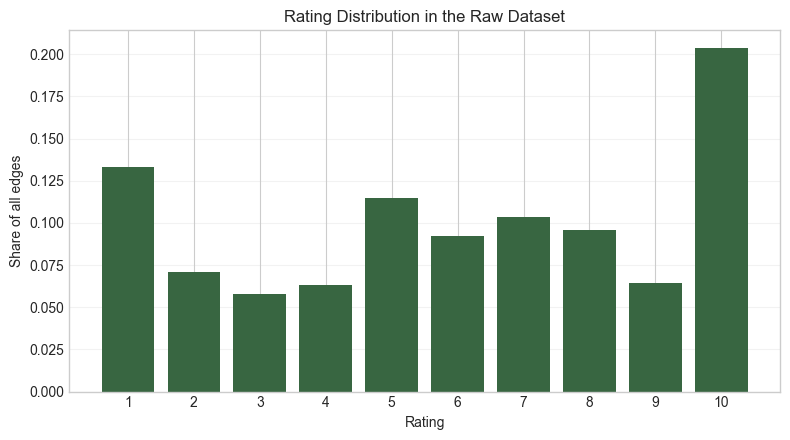

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(rating_distribution["rating"], rating_distribution["share"], color="#386641", width=0.8)
ax.set_title("Rating Distribution in the Raw Dataset")
ax.set_xlabel("Rating")
ax.set_ylabel("Share of all edges")
ax.set_xticks(rating_distribution["rating"])
ax.grid(alpha=0.25, axis="y")
plt.tight_layout()
plt.show()


## Why a Role-Based Bipartite Network?

One modeling choice matters for every later result:

we do **not** treat the same numeric identifier as a single universal node.

Instead, we separate the two structural roles:

- the **rater role**: sending scores
- the **profile role**: receiving scores

That choice keeps the directional meaning of the data intact and avoids unsupported identity assumptions across roles.


In [6]:
role_table = pd.DataFrame(
    [
        {
            "quantity": "unique_raters",
            "value": summary["unique_raters"],
            "why it matters": "This is the sending side of the network.",
        },
        {
            "quantity": "unique_profiles",
            "value": summary["unique_profiles"],
            "why it matters": "This is the receiving side of the network.",
        },
        {
            "quantity": "overlapping_user_ids",
            "value": summary["overlapping_user_ids"],
            "why it matters": "Many numeric IDs appear in both roles, so the roles must be separated analytically.",
        },
    ]
)

top_raters = pd.DataFrame(summary["top_raters"]).head(10)
top_profiles = pd.DataFrame(summary["top_profiles"]).head(10)

display(role_table)
display(Markdown("### Top raters by outgoing activity"))
display(top_raters)
display(Markdown("### Top profiles by incoming attention"))
display(top_profiles)


,quantity,value,why it matters
0,unique_raters,135360,This is the sending side of the network.
1,unique_profiles,168792,This is the receiving side of the network.
2,overlapping_user_ids,135360,"Many numeric IDs appear in both roles, so the ..."


### Top raters by outgoing activity

,rater_id,count
0,90281,25042
1,56793,21599
2,33640,19908
3,61437,18810
4,72352,18443
5,127228,18342
6,58766,18197
7,76083,18019
8,108319,17755
9,131977,17560


### Top profiles by incoming attention

,profile_id,count
0,606,33389
1,1440,28398
2,320,23649
3,228,23639
4,475,23113
5,48,21387
6,4963,21284
7,479,20634
8,44,18550
9,4920,18224


In [7]:
display(
    Markdown(
        f"""
        ## Interpretation

        ### Technical interpretation

        - The dataset is large enough to support full-network analysis: **{summary['edge_count']:,}** edges, **{summary['unique_raters']:,}** raters, and **{summary['unique_profiles']:,}** profiles.
        - The overlap between `rater_id` and `profile_id` values is substantial (**{summary['overlapping_user_ids']:,}** IDs), which justifies the role-based bipartite representation.
        - The score distribution is not flat; the upper end of the scale is used heavily, which matters for the later positive-layer analysis.

        ### Plain-language interpretation

        - This is a very large rating network, not a toy example.
        - Many users appear in both roles, so it would be misleading to mix "giving ratings" and "receiving ratings" into a single role.
        - People use high scores quite often, so it makes sense later to ask what happens when we focus on strong positive ratings.
        """
    )
)



        ## Interpretation

        ### Technical interpretation

        - The dataset is large enough to support full-network analysis: **17,359,346** edges, **135,360** raters, and **168,792** profiles.
        - The overlap between `rater_id` and `profile_id` values is substantial (**135,360** IDs), which justifies the role-based bipartite representation.
        - The score distribution is not flat; the upper end of the scale is used heavily, which matters for the later positive-layer analysis.

        ### Plain-language interpretation

        - This is a very large rating network, not a toy example.
        - Many users appear in both roles, so it would be misleading to mix "giving ratings" and "receiving ratings" into a single role.
        - People use high scores quite often, so it makes sense later to ask what happens when we focus on strong positive ratings.
        

## What This Notebook Produced

After running this notebook, the key cached artifact is:

- `outputs/data/dataset_summary.json`

The next notebook uses that summary together with the first study outputs to explore popularity, prestige, and inequality with tables and figures.
